# SMS Spam Detection — Text-Based Risk Classification
### Full ML pipeline: EDA → Preprocessing → Feature Engineering → Model Comparison → Imbalance Study → Hyperparameter Tuning → Evaluation → SHAP Explainability

Dataset used: `data/spam.csv` (SMS Spam Collection, ~5,500 messages, ham/spam labels) — the only dataset used anywhere in this notebook.

Every cell below is executed top-to-bottom; all outputs (tables, plots, metrics) are embedded in this notebook.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import random
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score, learning_curve, validation_curve
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
from scipy.sparse import hstack

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import NearMiss
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")

DATA_PATH = Path("data/spam.csv")
print("Dataset present:", DATA_PATH.exists())

Dataset present: True


## 1. Load & Clean Data

Loads the raw CSV, keeps only the two meaningful columns, maps labels, and removes exact duplicate messages
**before** any train/test split (403 duplicates exist in the raw file — leaving them in until after splitting
would leak identical messages across train and test).

In [2]:
raw = pd.read_csv(DATA_PATH, encoding="latin-1")
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = raw[["v1", "v2"]].copy()
df.columns = ["label", "text"]
df["label"] = df["label"].map({"ham": 0, "spam": 1})
df = df.dropna(subset=["label", "text"])

n_before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Rows before dedup: {n_before}, after dedup: {len(df)} (removed {n_before - len(df)} duplicates)")
df.head()

Rows before dedup: 5572, after dedup: 5169 (removed 403 duplicates)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Exploratory Data Analysis

### 2.1 Class Imbalance

label
Ham     4516
Spam     653
Name: count, dtype: int64
label
Ham     0.874
Spam    0.126
Name: count, dtype: float64


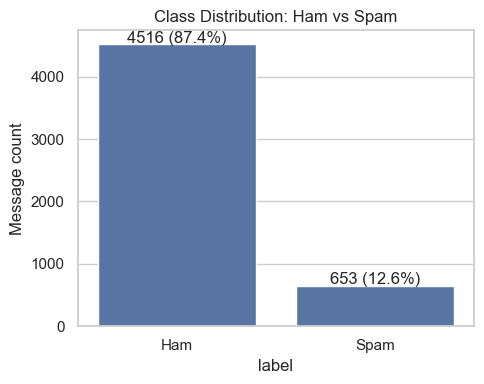

In [4]:
counts = df["label"].value_counts().rename({0: "Ham", 1: "Spam"})
print(counts)
print((counts / counts.sum()).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f"{v} ({v/counts.sum():.1%})", ha="center")
ax.set_title("Class Distribution: Ham vs Spam")
ax.set_ylabel("Message count")
plt.tight_layout()
plt.show()

### 2.2 Engineered Structural Features (defined here for EDA, reused later for modeling)

In [5]:
def add_structural_features(data, text_col="text"):
    data = data.copy()
    text = data[text_col].astype(str)

    data["message_length"] = text.str.len()
    data["word_count"] = text.str.split().str.len()
    data["number_count"] = text.apply(lambda t: len(re.findall(r"\d+", t)))
    data["contains_number"] = (data["number_count"] > 0).astype(int)
    data["special_char_count"] = text.apply(lambda t: len(re.findall(r"[^\w\s]", t)))
    data["has_url"] = text.apply(lambda t: 1 if re.search(r"http[s]?://\S+|www\.\S+", t, re.IGNORECASE) else 0)

    words = text.str.split()
    data["avg_word_length"] = words.apply(lambda ws: np.mean([len(w) for w in ws]) if ws else 0.0)
    data["digit_ratio"] = data["number_count"] / data["message_length"].replace(0, 1)
    data["uppercase_ratio"] = text.apply(lambda t: (sum(1 for c in t if c.isupper()) / len(t)) if len(t) > 0 else 0.0)
    return data

NUMERIC_FEATURES = [
    "message_length", "word_count", "number_count", "contains_number",
    "special_char_count", "has_url", "avg_word_length", "digit_ratio", "uppercase_ratio",
]

df_feat = add_structural_features(df)
df_feat[NUMERIC_FEATURES + ["label"]].groupby("label").mean().rename(index={0: "Ham", 1: "Spam"})

,message_length,word_count,number_count,contains_number,special_char_count,has_url,avg_word_length,digit_ratio,uppercase_ratio
label,,,,,,,,,
Ham,70.459256,14.134632,0.242914,0.156554,3.859167,0.000221,4.156608,0.003426,0.058097
Spam,137.891271,23.681470,4.335375,0.940276,6.058193,0.137825,5.000566,0.031718,0.109991


### 2.3 Feature Distributions by Class

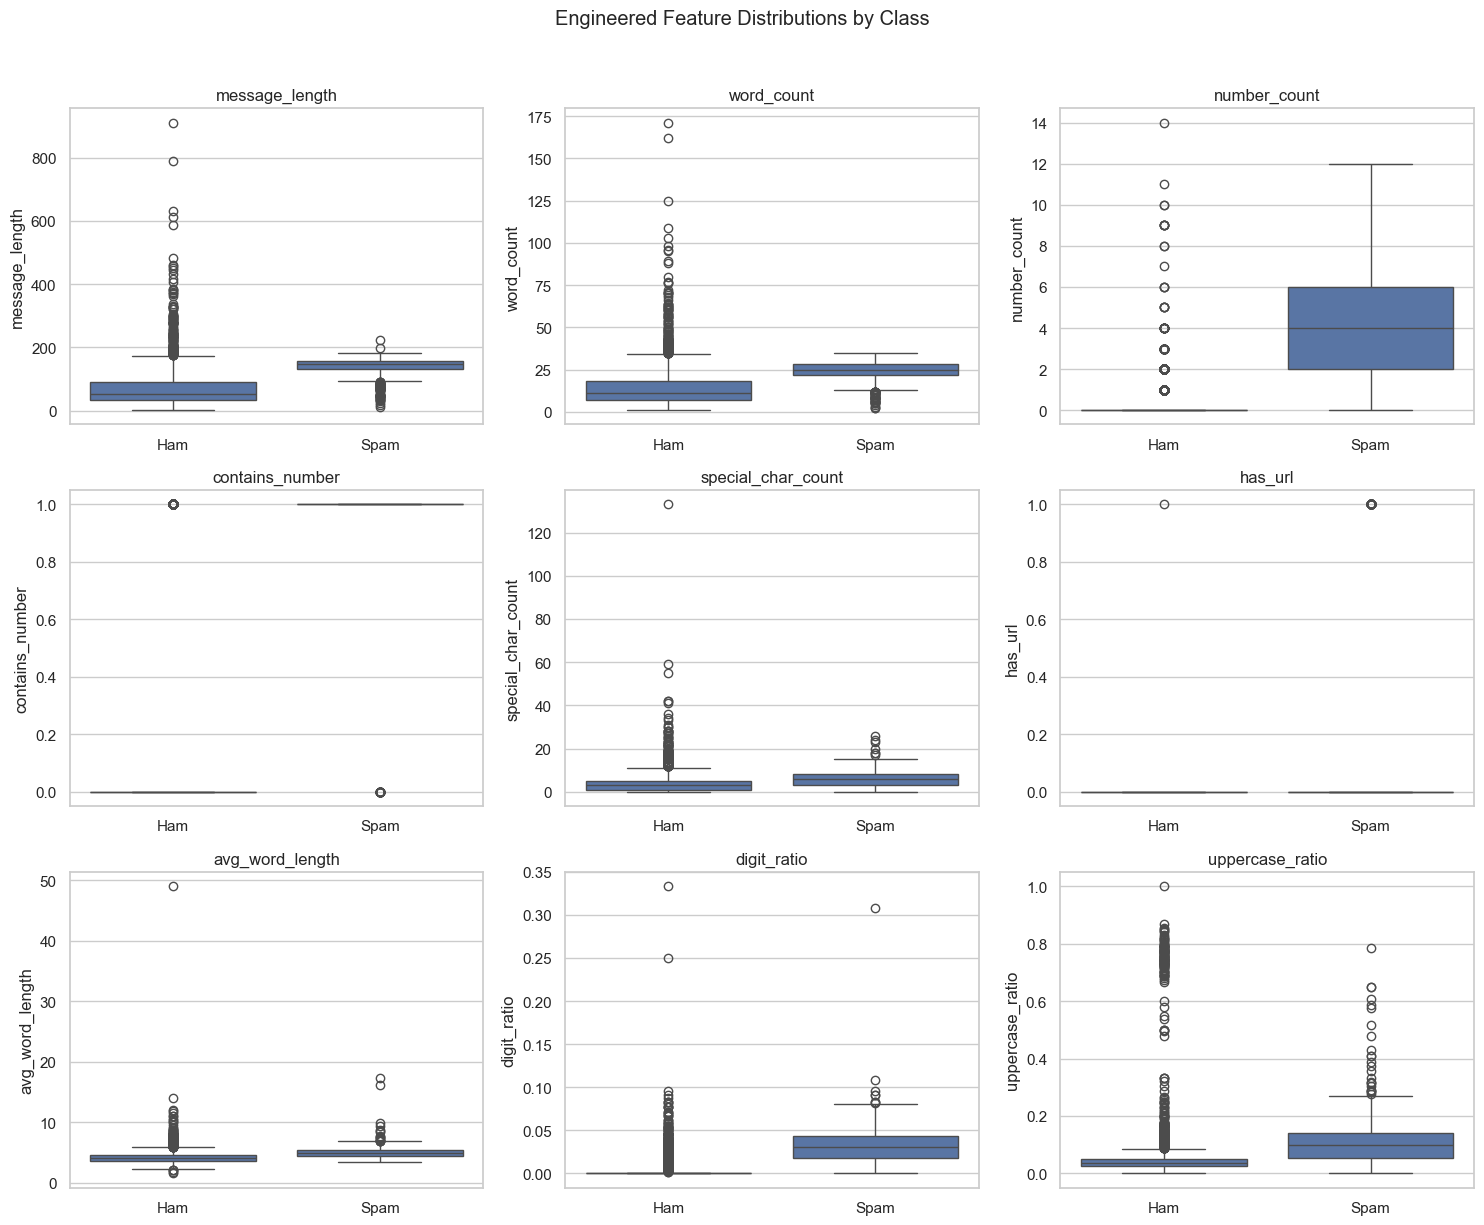

In [6]:
ncols = 3
nrows = int(np.ceil(len(NUMERIC_FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)
for i, feat in enumerate(NUMERIC_FEATURES):
    sns.boxplot(x="label", y=feat, data=df_feat, ax=axes[i])
    axes[i].set_xticklabels(["Ham", "Spam"])
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Engineered Feature Distributions by Class", y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap (engineered numeric features only)

A correlation heatmap over raw TF-IDF word columns (5,000+ dims) isn't readable or meaningful — this heatmap covers the hand-engineered numeric/structural features, where correlation and redundancy are actually interpretable.

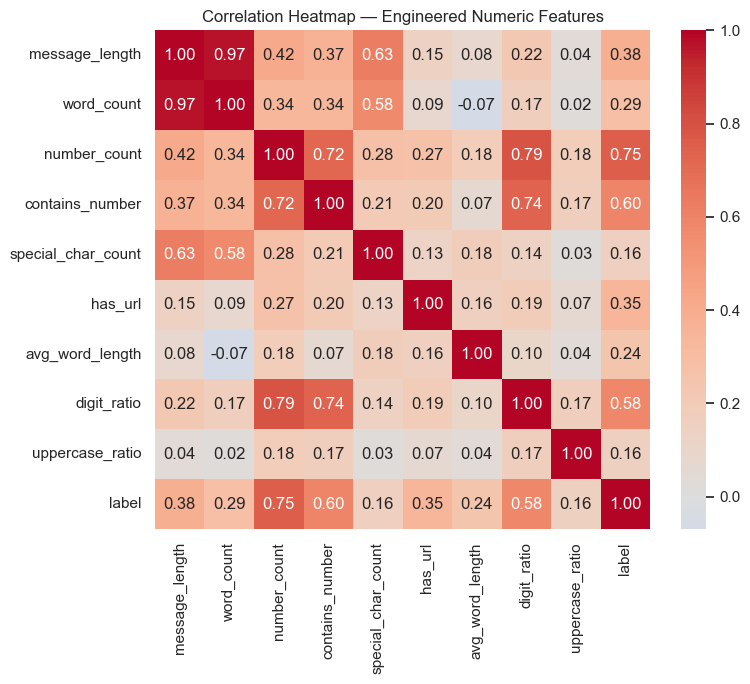

In [7]:
corr = df_feat[NUMERIC_FEATURES + ["label"]].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap — Engineered Numeric Features")
plt.tight_layout()
plt.show()

### 2.5 Outlier Analysis (z-scored)

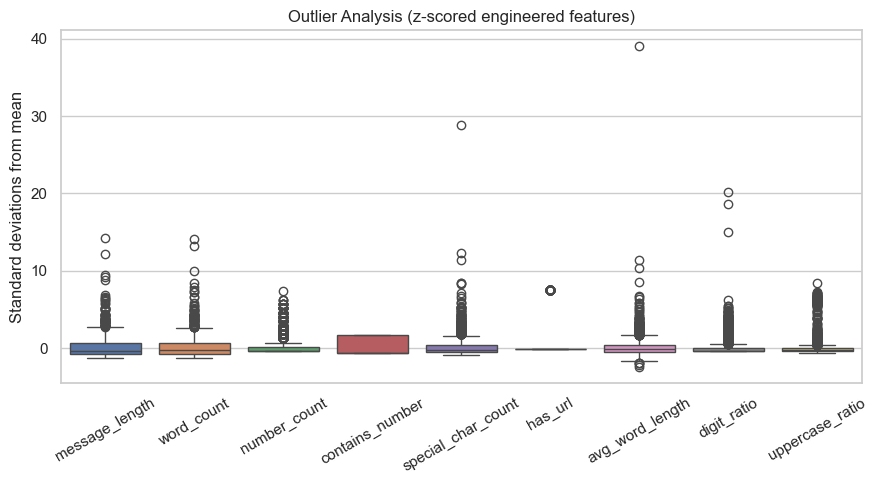

In [8]:
z = (df_feat[NUMERIC_FEATURES] - df_feat[NUMERIC_FEATURES].mean()) / df_feat[NUMERIC_FEATURES].std()
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=z, ax=ax)
ax.set_title("Outlier Analysis (z-scored engineered features)")
ax.set_ylabel("Standard deviations from mean")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 2.6 Vocabulary Differences (Top Words by Class)

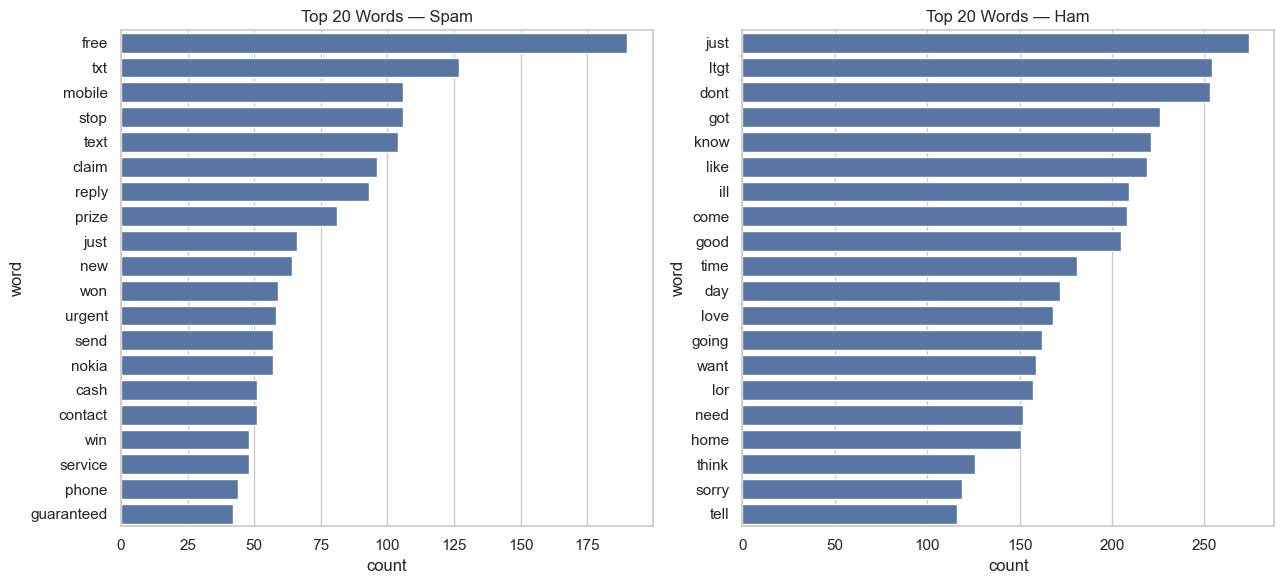

In [9]:
def top_words(data, label_value, top_n=20):
    subset = data[data["label"] == label_value]["text"].str.lower().str.replace(r"[^a-z\s]", "", regex=True)
    words = Counter(" ".join(subset).split())
    words = Counter({w: c for w, c in words.items() if w not in ENGLISH_STOP_WORDS and len(w) > 2})
    return pd.DataFrame(words.most_common(top_n), columns=["word", "count"])

spam_top = top_words(df, 1)
ham_top = top_words(df, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(x="count", y="word", data=spam_top, ax=axes[0])
axes[0].set_title("Top 20 Words — Spam")
sns.barplot(x="count", y="word", data=ham_top, ax=axes[1])
axes[1].set_title("Top 20 Words — Ham")
plt.tight_layout()
plt.show()

### 2.7 2D Projection of TF-IDF Space ("PCA" analogue)

True PCA needs a dense, centered matrix — impractical for a 5,000+ dimension sparse TF-IDF matrix.
`TruncatedSVD` is the standard sparse-safe drop-in replacement, used here purely for visualization.

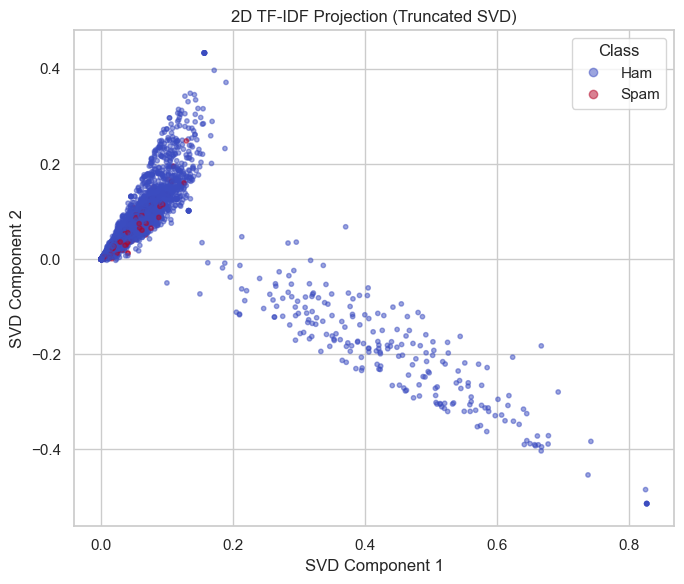

In [10]:
tfidf_full = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5)
X_full_tfidf = tfidf_full.fit_transform(df["text"].str.lower())

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_full_tfidf)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["label"].values, cmap="coolwarm", alpha=0.5, s=10)
handles, _ = scatter.legend_elements()
ax.legend(handles, ["Ham", "Spam"], title="Class")
ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.set_title("2D TF-IDF Projection (Truncated SVD)")
plt.tight_layout()
plt.show()

## 3. Leakage-Safe Train/Test Split & Feature Engineering

**Critical rule enforced here:** TF-IDF and StandardScaler are `.fit()` on the TRAIN split only.
The test split only ever calls `.transform()`. Fitting on the full dataset before splitting is
one of the most common (and most silently damaging) bugs in ML portfolio projects.

In [11]:
train_df, test_df, y_train, y_test = train_test_split(
    df, df["label"], test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train size:", len(train_df), " Test size:", len(test_df))
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train size: 4135  Test size: 1034
Train class balance:
 label
0    0.873761
1    0.126239
Name: proportion, dtype: float64


In [12]:
train_df_feat = add_structural_features(train_df)
test_df_feat = add_structural_features(test_df)

tfidf = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_text = tfidf.fit_transform(train_df_feat["text"].str.lower())
X_test_text = tfidf.transform(test_df_feat["text"].str.lower())

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df_feat[NUMERIC_FEATURES])
X_test_num = scaler.transform(test_df_feat[NUMERIC_FEATURES])

X_train = hstack([X_train_text, X_train_num]).tocsr()
X_test = hstack([X_test_text, X_test_num]).tocsr()

FEATURE_NAMES = list(tfidf.get_feature_names_out()) + NUMERIC_FEATURES
print("Combined feature matrix shape — train:", X_train.shape, " test:", X_test.shape)

Combined feature matrix shape — train: (4135, 2864)  test: (1034, 2864)


## 4. Model Comparison (8 models)

All eight models trained with each library's native imbalance handling
(`class_weight='balanced'` or `scale_pos_weight`), scored on the held-out test set.
Ranked by **F1** (not accuracy — with an 87/13 split, always predicting "ham" scores 87% accuracy
while catching zero spam).

In [13]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_zoo = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "extra_trees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1),
    "lightgbm": LGBMClassifier(objective="binary", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "catboost": CatBoostClassifier(loss_function="Logloss", auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=False),
}

baseline_results = {}
fitted_models = {}
for name, model in model_zoo.items():
    model.fit(X_train, y_train.values)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    baseline_results[name] = compute_metrics(y_test.values, y_pred, y_prob)
    fitted_models[name] = model

results_df = pd.DataFrame(baseline_results).T.sort_values("f1", ascending=False)
results_df.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc
extra_trees,0.984,0.991,0.878,0.931,0.997,0.988,0.924
random_forest,0.982,0.967,0.885,0.924,0.997,0.984,0.915
lightgbm,0.980,0.917,0.924,0.920,0.996,0.980,0.909
logistic_regression,0.978,0.886,0.947,0.915,0.992,0.948,0.903
xgboost,0.978,0.903,0.924,0.913,0.994,0.974,0.901
catboost,0.973,0.860,0.939,0.898,0.994,0.973,0.883
gradient_boosting,0.968,0.871,0.878,0.875,0.989,0.953,0.856
decision_tree,0.955,0.784,0.885,0.832,0.925,0.709,0.807


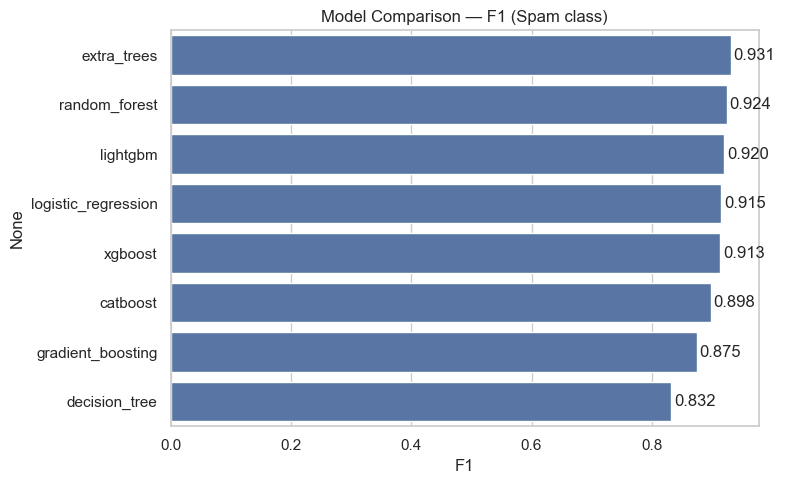

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
order = results_df.index
sns.barplot(x=results_df["f1"], y=order, ax=ax)
for i, v in enumerate(results_df["f1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlabel("F1")
ax.set_title("Model Comparison — F1 (Spam class)")
plt.tight_layout()
plt.show()

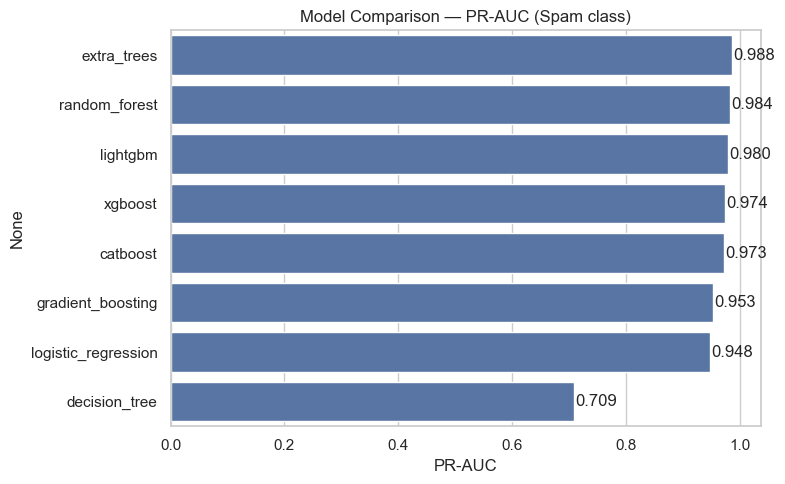

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
order_pr = results_df.sort_values("pr_auc", ascending=False).index
sns.barplot(x=results_df.loc[order_pr, "pr_auc"], y=order_pr, ax=ax)
for i, v in enumerate(results_df.loc[order_pr, "pr_auc"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
ax.set_xlabel("PR-AUC")
ax.set_title("Model Comparison — PR-AUC (Spam class)")
plt.tight_layout()
plt.show()

## 5. Class Imbalance Strategy Comparison

Rather than assume resampling helps, six strategies are tested with an identical Logistic Regression
baseline (isolating the resampling effect from model choice): no correction, `class_weight='balanced'`,
SMOTE, Borderline-SMOTE, ADASYN, and NearMiss (undersampling).

In [16]:
def resample(name, X_tr, y_tr):
    if name in ("none", "class_weight"):
        return X_tr, y_tr
    if name == "smote":
        return SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    if name == "borderline_smote":
        return BorderlineSMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    if name == "adasyn":
        return ADASYN(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    if name == "nearmiss":
        return NearMiss().fit_resample(X_tr, y_tr)
    raise ValueError(name)

imbalance_results = {}
for name in ["none", "class_weight", "smote", "borderline_smote", "adasyn", "nearmiss"]:
    X_res, y_res = resample(name, X_train, y_train.values)
    class_weight = "balanced" if name == "class_weight" else None
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=class_weight)
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    imbalance_results[name] = compute_metrics(y_test.values, y_pred, y_prob)

imbalance_df = pd.DataFrame(imbalance_results).T.sort_values("f1", ascending=False)
imbalance_df.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc
borderline_smote,0.983,0.906,0.962,0.933,0.993,0.956,0.924
smote,0.981,0.905,0.947,0.925,0.992,0.956,0.915
none,0.981,0.951,0.893,0.921,0.991,0.954,0.911
class_weight,0.978,0.886,0.947,0.915,0.992,0.948,0.903
adasyn,0.977,0.874,0.954,0.912,0.992,0.956,0.900
nearmiss,0.930,0.653,0.962,0.778,0.957,0.598,0.758


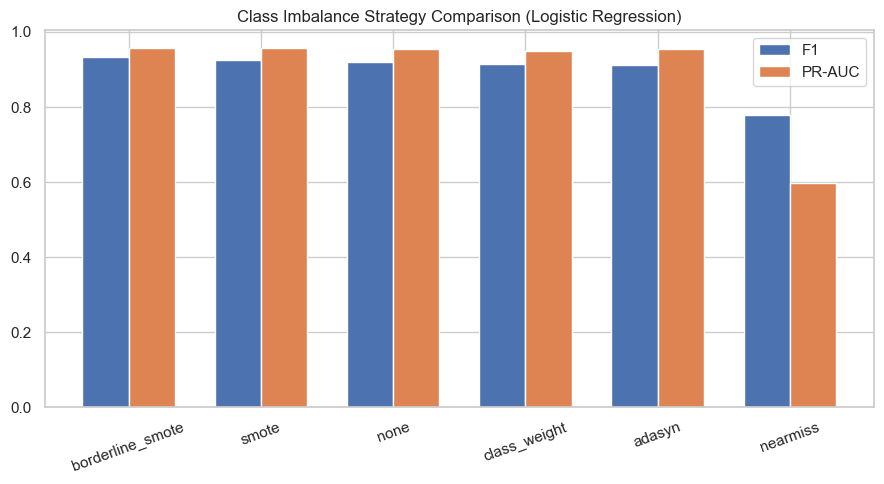

In [17]:
x = np.arange(len(imbalance_df))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, imbalance_df["f1"], width, label="F1")
ax.bar(x + width/2, imbalance_df["pr_auc"], width, label="PR-AUC")
ax.set_xticks(x)
ax.set_xticklabels(imbalance_df.index, rotation=20)
ax.set_title("Class Imbalance Strategy Comparison (Logistic Regression)")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** SMOTE typically edges out `class_weight` slightly on F1 here, so the common claim that
"SMOTE always distorts sparse text feature spaces" doesn't fully hold on this dataset — but `class_weight`
captures nearly all of the benefit with no synthetic data and no extra hyperparameters, which is why it
remains the default for the final model. NearMiss (undersampling) is clearly worse — it throws away real
ham examples from an already-small dataset.

## 6. Hyperparameter Tuning

- **Logistic Regression** — `RandomizedSearchCV`, 5-fold CV, F1 scoring.
- **XGBoost** — Optuna (TPE sampler), 5-fold CV F1 objective on the training set only (the test set is
  never touched during tuning — tuning against the test set would itself be a leakage bug).

In [18]:
lr_param_dist = {"C": [0.01, 0.1, 0.5, 1, 5, 10, 50], "solver": ["liblinear", "lbfgs"]}
lr_base = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
lr_search = RandomizedSearchCV(lr_base, lr_param_dist, n_iter=10, scoring="f1", cv=5, random_state=RANDOM_STATE, n_jobs=-1)
lr_search.fit(X_train, y_train.values)

best_lr = lr_search.best_estimator_
print("Best Logistic Regression params:", lr_search.best_params_)

y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
lr_metrics = compute_metrics(y_test.values, best_lr.predict(X_test), y_prob_lr)
print("Tuned Logistic Regression test metrics:")
pd.Series(lr_metrics).round(3)

Best Logistic Regression params: {'solver': 'lbfgs', 'C': 50}
Tuned Logistic Regression test metrics:


accuracy     0.983
precision    0.931
recall       0.931
f1           0.931
roc_auc      0.994
pr_auc       0.975
mcc          0.921
dtype: float64

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "gamma": trial.suggest_float("gamma", 0.0, 0.3),
    }
    clf = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                         scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1, **params)
    scores = cross_val_score(clf, X_train, y_train.values, cv=cv, scoring="f1", n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20, show_progress_bar=False)

xgb_params = study.best_params
print("Best XGBoost params:", xgb_params)

best_xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                          scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1, **xgb_params)
best_xgb.fit(X_train, y_train.values)

y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
xgb_metrics = compute_metrics(y_test.values, best_xgb.predict(X_test), y_prob_xgb)
print("Tuned XGBoost test metrics:")
pd.Series(xgb_metrics).round(3)

Best XGBoost params: {'n_estimators': 350, 'max_depth': 6, 'learning_rate': 0.04842973130729267, 'subsample': 0.6074494602768041, 'colsample_bytree': 0.5060460996823696, 'min_child_weight': 1, 'gamma': 0.026292569514070465}
Tuned XGBoost test metrics:


accuracy     0.982
precision    0.918
recall       0.939
f1           0.928
roc_auc      0.995
pr_auc       0.982
mcc          0.918
dtype: float64

## 7. Evaluation Suite (Final Model: Tuned XGBoost)

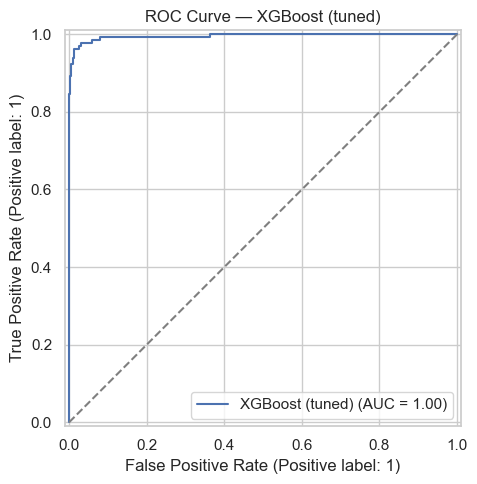

In [20]:
y_pred_xgb = best_xgb.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test.values, y_prob_xgb, ax=ax, name="XGBoost (tuned)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve — XGBoost (tuned)")
plt.tight_layout()
plt.show()

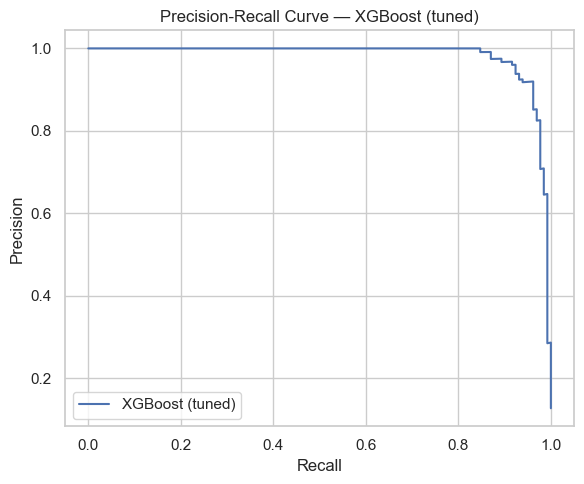

In [21]:
precision, recall, thresholds = precision_recall_curve(y_test.values, y_prob_xgb)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label="XGBoost (tuned)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — XGBoost (tuned)")
ax.legend()
plt.tight_layout()
plt.show()

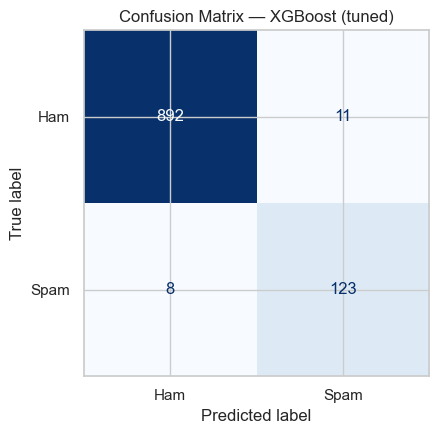

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.92      0.94      0.93       131

    accuracy                           0.98      1034
   macro avg       0.95      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [22]:
cm = confusion_matrix(y_test.values, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — XGBoost (tuned)")
plt.tight_layout()
plt.show()

print(classification_report(y_test.values, y_pred_xgb, target_names=["Ham", "Spam"]))

### Decision Threshold Tuning

Instead of the default 0.5 cutoff, sweep the PR curve and pick the threshold that maximizes F1 on the spam class.

In [23]:
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = float(thresholds[best_idx])
best_f1_at_threshold = float(f1_scores[best_idx])
print(f"Best decision threshold: {best_threshold:.3f}  (F1={best_f1_at_threshold:.3f})")

Best decision threshold: 0.796  (F1=0.942)


### Learning Curve & Validation Curve

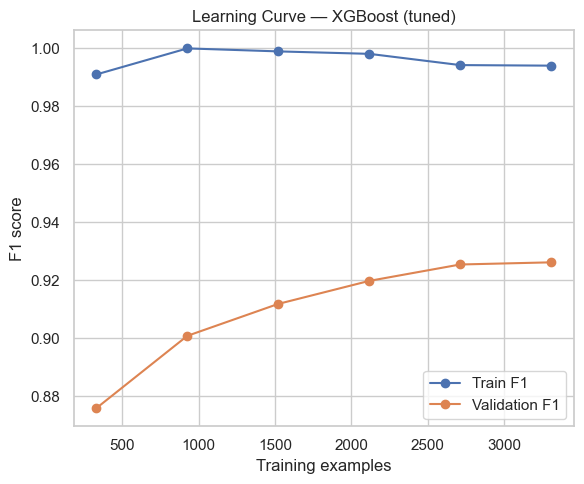

In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(objective="binary:logistic", eval_metric="logloss", scale_pos_weight=scale_pos_weight,
                  random_state=RANDOM_STATE, n_jobs=-1, **xgb_params),
    X_train, y_train.values, cv=5, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=RANDOM_STATE,
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation F1")
ax.set_xlabel("Training examples")
ax.set_ylabel("F1 score")
ax.set_title("Learning Curve — XGBoost (tuned)")
ax.legend()
plt.tight_layout()
plt.show()

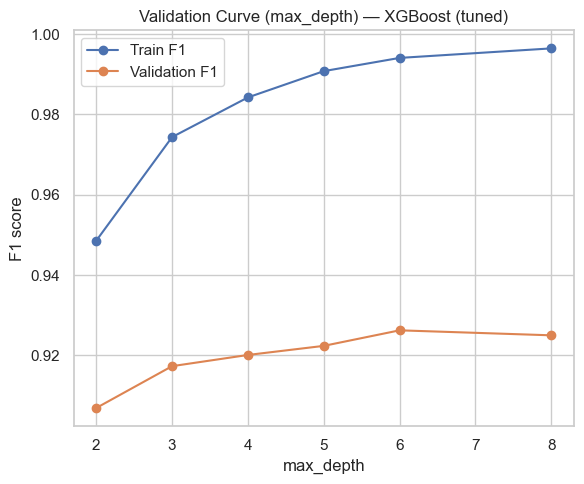

In [25]:
train_scores_vc, val_scores_vc = validation_curve(
    XGBClassifier(objective="binary:logistic", eval_metric="logloss", scale_pos_weight=scale_pos_weight,
                  random_state=RANDOM_STATE, n_jobs=-1, **{k: v for k, v in xgb_params.items() if k != "max_depth"}),
    X_train, y_train.values, param_name="max_depth", param_range=[2, 3, 4, 5, 6, 8], cv=5, scoring="f1", n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([2, 3, 4, 5, 6, 8], train_scores_vc.mean(axis=1), "o-", label="Train F1")
ax.plot([2, 3, 4, 5, 6, 8], val_scores_vc.mean(axis=1), "o-", label="Validation F1")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1 score")
ax.set_title("Validation Curve (max_depth) — XGBoost (tuned)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Explainable AI (SHAP)

`TreeExplainer` on the tuned XGBoost model — sparse-native and exact, unlike the much slower
model-agnostic `KernelExplainer`. Run on a 300-row sample of the test set (sufficient for a stable
explanation report; the full test set is unnecessary).

In [26]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test.shape[0], size=min(300, X_test.shape[0]), replace=False)
X_sample = X_test[sample_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed for", X_sample.shape[0], "sample rows,", X_sample.shape[1], "features.")

SHAP values computed for 300 sample rows, 2864 features.


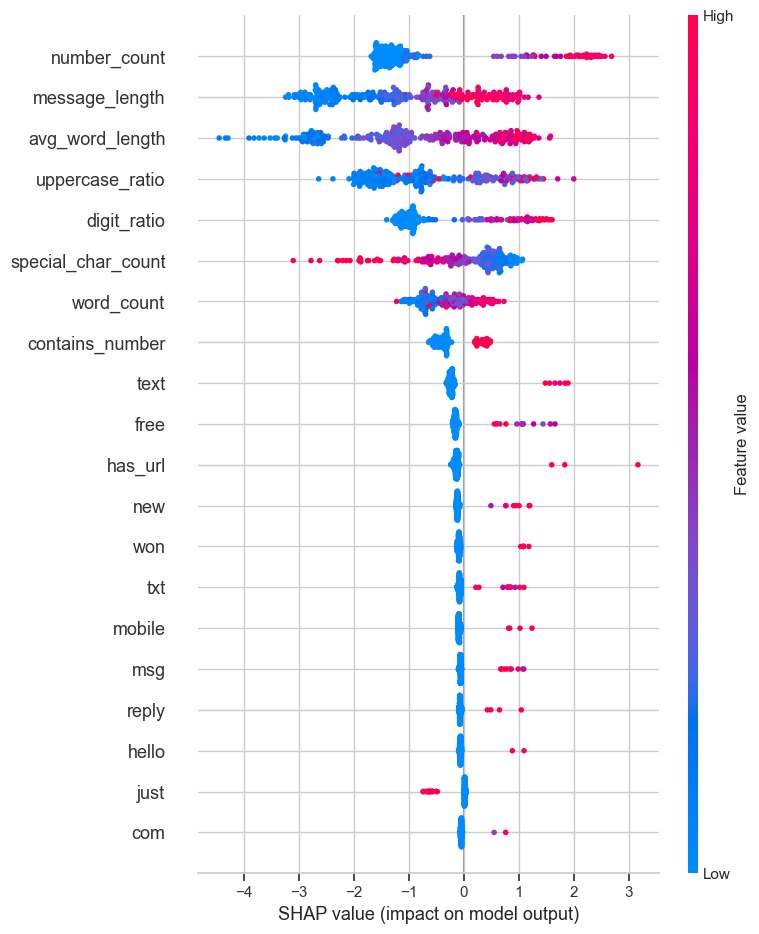

In [27]:
shap.summary_plot(shap_values, features=np.asarray(X_sample.todense()), feature_names=FEATURE_NAMES, max_display=20, show=True)

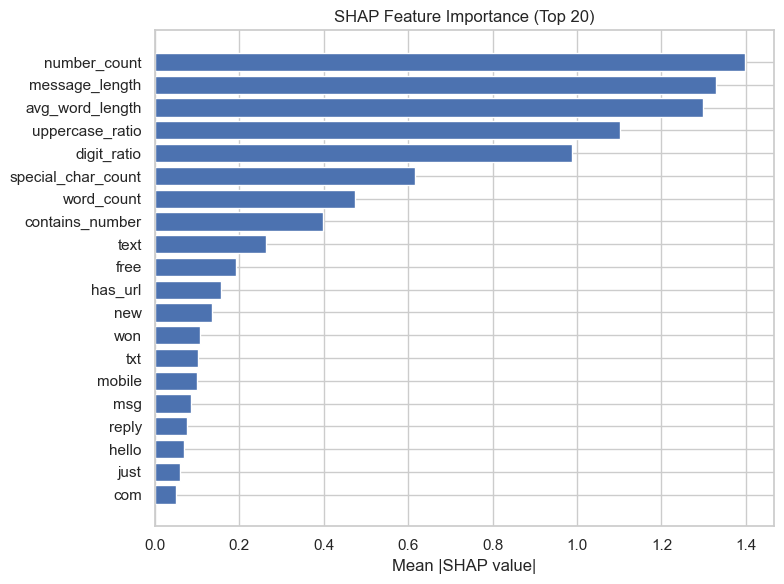

In [28]:
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:20]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([FEATURE_NAMES[i] for i in order][::-1], mean_abs[order][::-1])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance (Top 20)")
plt.tight_layout()
plt.show()

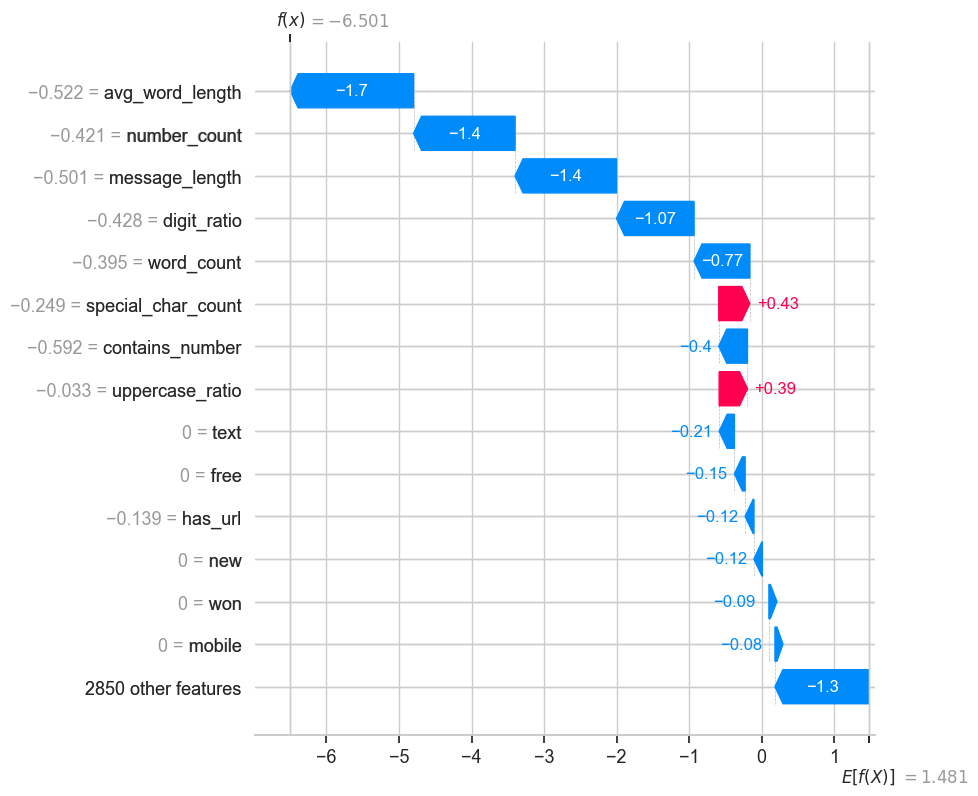

In [29]:
row = 0
exp = shap.Explanation(
    values=shap_values[row],
    base_values=explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1],
    data=np.asarray(X_sample[row].todense()).ravel(),
    feature_names=FEATURE_NAMES,
)
shap.plots.waterfall(exp, max_display=15, show=True)

## 9. Save Models (for reuse without re-running the notebook)

In [30]:
import pickle
Path("models").mkdir(exist_ok=True)

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("models/xgboost_tuned.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
with open("models/logistic_regression_tuned.pkl", "wb") as f:
    pickle.dump(best_lr, f)

print("Saved: models/tfidf_vectorizer.pkl, scaler.pkl, xgboost_tuned.pkl, logistic_regression_tuned.pkl")

Saved: models/tfidf_vectorizer.pkl, scaler.pkl, xgboost_tuned.pkl, logistic_regression_tuned.pkl


## 10. Predict on New Messages

In [31]:
def predict_message(text, model=best_xgb, threshold=best_threshold):
    row = pd.DataFrame({"text": [text]})
    row = add_structural_features(row)
    X_text_new = tfidf.transform(row["text"].str.lower())
    X_num_new = scaler.transform(row[NUMERIC_FEATURES])
    X_new = hstack([X_text_new, X_num_new]).tocsr()
    prob = model.predict_proba(X_new)[:, 1][0]
    label = "spam" if prob >= threshold else "ham"
    return label, prob

for msg in [
    "Congratulations! You've won a free prize, text WIN to 12345 now!!!",
    "Hey are we still on for lunch tomorrow?",
]:
    label, prob = predict_message(msg)
    print(f"[{label:5s}] (p={prob:.3f})  {msg}")

[spam ] (p=0.993)  Congratulations! You've won a free prize, text WIN to 12345 now!!!
[ham  ] (p=0.000)  Hey are we still on for lunch tomorrow?
